# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - B.Rachana

# **Project Summary -**

The project focuses on analyzing zomato restaurant data and customer review , it help in understanding restaurant performance, customer preferences, and the factors that help in improving the restaurant ratings.There are two datasets Zomato_Restaurant_names_and_Metadata and Zomato_Restaurant_reviews.Zomato_Restaurant_names_and_Metadata consist of name,links indicating the location ,cost collections,cuisines and timings of the restaurant.The Zomato_Restaurant_reviews consist of the restaurant name ,customer name, the review ,rating ,metadata,time and picture.Total 10000 reviews given by customer and 105 restaurant information provided.There are 36 duplicate in the Zomato_Restaurant_reviews dataset. These details can help restaurant improve their services, optimize pricing , and improve customer satisfaction. The analysis began with understanding the dataset structure ,identifying the data types and expplloriing the overall distribution. Duplicate records were checked and in the reviews dataset contained some duplicate entries, which were removed to maintain the data quality and help in incresing the accuracy analysis. After understanding the data, the next step is data cleaning and preprocessing. It includes removing duplicate rows and missing data in the dataset and preparing it for analysis. Data cleaning is an very important step in the process as it ensures the accuracy of the results obtained from the analysis. After cleaning the data, exploratory data analysis is performed using different charts and visualizations. The analysis is performed based on the UBM rule, which includes Univariate, Bivariate, and Multivariate analysis. Univariate analysis helps in understanding the distribution of variables such as ratings, cost for two people, and restaurant types. Bivariate analysis is performed to understand the relationship between two variables, such as votes and ratings, cost and ratings, and online ordering availability and restaurant popularity. Multivariate analysis helps in understanding how different variables interact with each other. From these visualizations, some interesting facts were discovered. First, it was seen that a number of restaurants belonged to a mid-range cost category.The restaurants with a mid-range price can be said to be common in this data set. Secondly, restaurants with more votes seem to be associated with higher ratings. Hence, restaurants with more votes can be said to be associated with higher ratings or customer satisfaction. Thirdly, restaurants with online ordering services seem to be more popular. Fourthly, it can be said that location and type of cuisine can affect restaurants in terms of popularity and ratings.Machine learning algorithms can be used for predicting ratings for restaurants based on different features such as votes, cost for two people, etc. Different algorithms can be used for this purpose, and their performances can be evaluated using different parameters. From this project,we will get to know how data analysis can be used for better business decisions by understanding different aspects related to restaurants and their customers.These things can help restaurant owners understand customer preferences and improve their services. They can also use this information to make better decisions about pricing, location, and customer experience to attract more customers.It also helps restaurants to understand the features that help in maintaing the higher ratings . Using these information, restaurants can focus on improving quality, service, and online services to grow their business.


# **Problem Statement**


With the rapid growth of online food delivery platforms like Zomato, customers now depend heavily on ratings, reviews, and restaurant information before choosing where to eat or order food, because there are thousands of restaurants, it is difficult for restaurant owners and businesses to clearly understand customer preferences and the factors that help in incerasing the  restaurant popularity and ratings. This project aims to analyze Zomato restaurant data and customer reviews to gain better information about restaurant performance and customer behavior. By performing data analysis and creating visualizations, the project tries to identify patterns related to ratings, cost for two people, number of votes and service features such as online ordering and table booking. Machine learning techniques are used to predict restaurant ratings based on different features in the dataset. The goal of this analysis is to help businesses understand what customers value the most and how different factors affect restaurant success. The information generated from this project can support restaurant owners in improving their services, pricing strategies, and overall customer experience, which help in improving the customer satisfaction and better business performance.


### Import Libraries

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [ ]:
# Load Dataset
# Load Dataset

restaurants = pd.read_csv('/content/Zomato_Restaurant_names_and_Metadata.csv')
reviews = pd.read_csv('/content/Zomato_Restaurant_reviews.csv')

print("Restaurant Dataset Shape:", restaurants.shape)
print("Reviews Dataset Shape:", reviews.shape)

Restaurant Dataset Shape: (105, 6)
Reviews Dataset Shape: (10000, 7)


### Dataset First View

In [ ]:
# Dataset First Look
restaurants.head()
reviews.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns count

In [ ]:
print("Restaurants Rows:", restaurants.shape[0])
print("Restaurants Columns:", restaurants.shape[1])
print("Reviews Rows:", reviews.shape[0])
print("Reviews Columns:", reviews.shape[1])

Restaurants Rows: 105
Restaurants Columns: 6
Reviews Rows: 10000
Reviews Columns: 7


### Dataset Information

In [ ]:
# Dataset Info
restaurants.info()
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
print(restaurants.duplicated().sum())
print(reviews.duplicated().sum())

0
36


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
print(restaurants.isnull().sum())
print("____________")
print(reviews.isnull().sum())

Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64
____________
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64


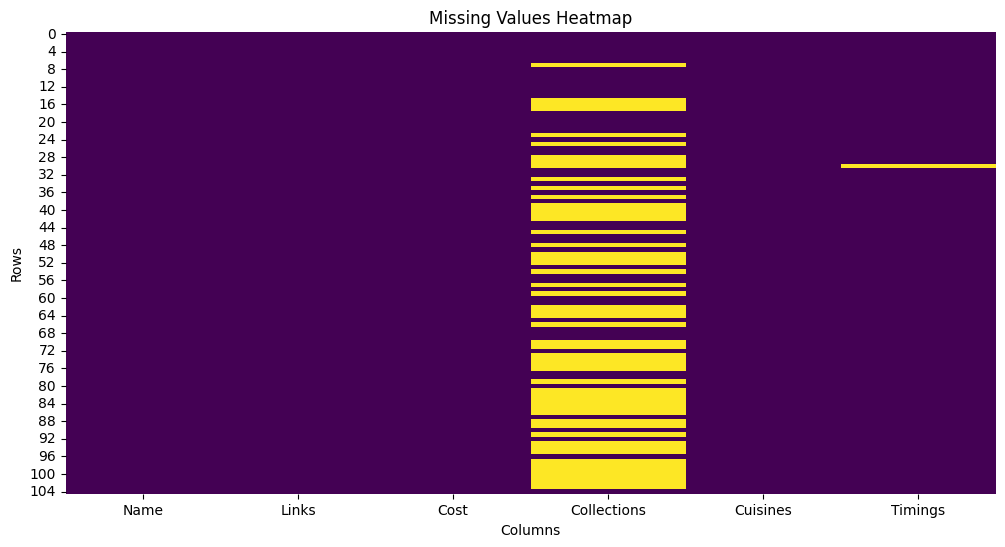

In [ ]:
# Visualizing the missing value
plt.figure(figsize=(12,6))
sns.heatmap(restaurants.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

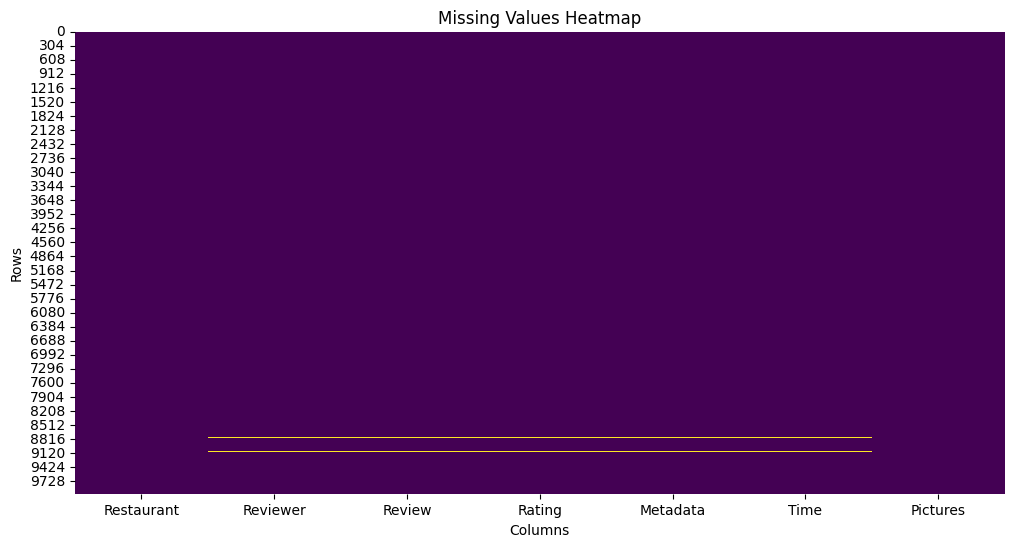

In [ ]:
# Visualizing the missing value
plt.figure(figsize=(12,6))
sns.heatmap(reviews.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

### What did you know about your dataset?

The dataset contains the information of the zomato restaurant and the customer review which help in knowing the customer preference and restaurent perfromanace.There are two datasets Zomato_Restaurant_names_and_Metadata and Zomato_Restaurant_reviews.Zomato_Restaurant_names_and_Metadata consist of name,links indicating the location ,cost collections,cuisines and timings of the restaurant.The Zomato_Restaurant_reviews consist of the restaurant name ,customer name, the review ,rating ,metadata,time and picture.Total 10000 reviews given by customer and 105 restaurant information provided.There are 36 duplicate in the Zomato_Restaurant_reviews dataset. These details can help restaurant improve their services, optimize pricing , and improve customer satisfaction

## ***Understanding Your Variables***

In [ ]:
# Dataset Columns
print(restaurants.columns)
print(reviews.columns)

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')
Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')


In [ ]:
# Dataset Describe
print(restaurants.describe())
print("____")
print(reviews.describe())

                   Name                                              Links  \
count               105                                                105   
unique              105                                                105   
top     Beyond Flavours  https://www.zomato.com/hyderabad/beyond-flavou...   
freq                  1                                                  1   

       Cost                                  Collections  \
count   105                                           51   
unique   29                                           42   
top     500  Food Hygiene Rated Restaurants in Hyderabad   
freq     13                                            4   

                     Cuisines         Timings  
count                     105             104  
unique                     92              77  
top     North Indian, Chinese  11 AM to 11 PM  
freq                        4               6  
____
           Pictures
count  10000.000000
mean       0.748600
std

### Variables Description

The dataset contains various variables that provide information about restaurants and customer reviews. Each variable represents a specific feature of the restaurant or the review given by customers.
These variables help in understanding restaurant characteristics, customer preferences, and factors that influence restaurant ratings and popularity.

* **Restaurant Name** - The name of the restaurant listed on the Zomato platform
* **Links(Location)** - The area or place where the restaurant is located


*   **Cost** - The cost of the food at the restaurant
*   **Timmings** - The timmmings of the restaurant that when it get started and when it will get close


* **Cuisines** - The type of food served by the restaurant, such as Indian, Chinese, Italian, etc
* **Review Text** - The feedback or comments provided by customers
* **Reviewer Name** - The name of the customer who provided the review
* **Rating ** - The rating given by the customers for the restaurant
* **Time** - The time or date when the review was posted



### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for col in restaurants.columns:
    print(col, restaurants[col].nunique())

Name 105
Links 105
Cost 29
Collections 42
Cuisines 92
Timings 77


In [ ]:
for col in reviews.columns:
    print(col, reviews[col].nunique())

Restaurant 100
Reviewer 7446
Review 9364
Rating 10
Metadata 2477
Time 9782
Pictures 36


##***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.

# 1. Create copies of datasets
res = restaurants.copy()
rev = reviews.copy()

# 2. Check duplicate values
print("Duplicate values in restaurants dataset:", res.duplicated().sum())
print("Duplicate values in reviews dataset:", rev.duplicated().sum())

# 3. Remove duplicate rows
res.drop_duplicates(inplace=True)
rev.drop_duplicates(inplace=True)

# 4. Check missing values
print(res.isnull().sum())
print(rev.isnull().sum())

# 5. Handle missing values
res.fillna(method='ffill', inplace=True)
rev.fillna(method='ffill', inplace=True)

# 6. Convert Cost column to numeric (corrected column name)
res['Cost'] = res['Cost'].astype(str)
res['Cost'] = res['Cost'].str.replace(',', '')
res['Cost'] = pd.to_numeric(res['Cost'], errors='coerce')

# 7. Clean Rating column (corrected column name and DataFrame)
rev['Rating'] = rev['Rating'].astype(str)
rev['Rating'] = rev['Rating'].str.replace('/5', '')
rev['Rating'] = pd.to_numeric(rev['Rating'], errors='coerce')

# Convert Time column to datetime
rev['Time'] = pd.to_datetime(rev['Time'], errors='coerce')

# Extract hour from time
rev['Hour'] = rev['Time'].dt.hour

# 8. Final dataset check
print("restaurants dataset:", res.shape)
print("reviews dataset:", rev.shape)


Duplicate values in restaurants dataset: 0
Duplicate values in reviews dataset: 36
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64
Restaurant    0
Reviewer      2
Review        9
Rating        2
Metadata      2
Time          2
Pictures      0
Hour          2
dtype: int64
restaurants dataset: (105, 6)
reviews dataset: (9964, 8)


### What all manipulations have you done and insights you found?

During the data wrangling process, the datasets were first examined to understand their structure and columns. Duplicate rows were identified and removed to avoid repeated data. Missing values were checked and handled to keep the dataset clean. Some columns were also cleaned and converted into numeric format. For example, commas were removed from the cost column before converting it into numbers, and the “/5” part was removed from the rating column. After these steps, the dataset became clean and ready for analysis. From this process, it was observed that the dataset contained a few duplicate and missing values, and cleaning the cost and rating columns made the data easier to analyze and use for further visualization and machine learning.


## ***Data Vizualization & Experimenting with charts : Understand the relationships between variables***

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#### Chart - 1

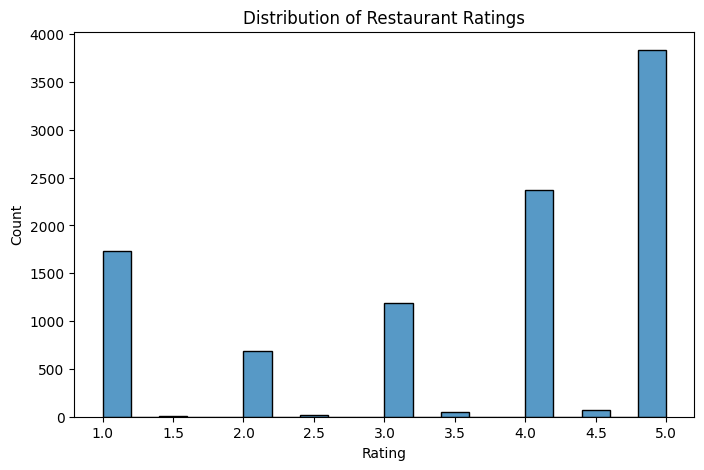

In [ ]:
# Chart - 1 visualization code
# Histogram for Ratings Distribution

plt.figure(figsize=(8,5))
sns.histplot(rev['Rating'], bins=20)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was used to understand how restaurant ratings are distributed in the dataset. It helps visualize how frequently different rating values appear.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that most restaurants have ratings in the higher range, mainly between around 3.5 and 4.5. Very few restaurants have extremely low ratings. This indicates that most restaurants listed in the dataset generally receive good feedback from customers

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help restaurants understand that maintaining good service is important to stay competitive. If many restaurants already have high ratings, businesses must continue improving quality to stand out. Restaurants with lower ratings may experience negative growth because customers usually prefer places with higher ratings.

#### Chart - 2

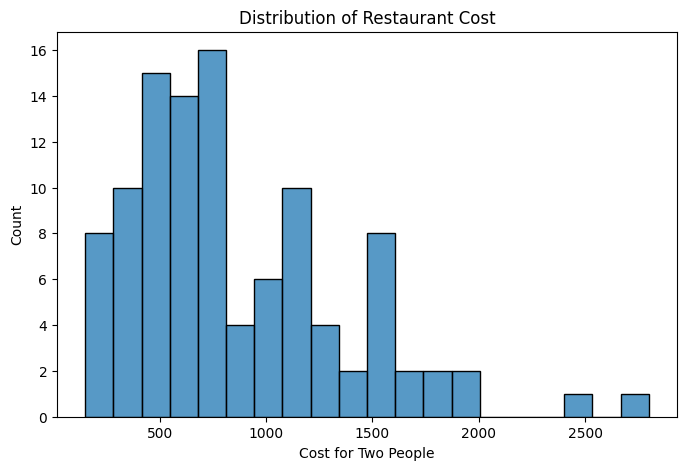

In [ ]:
# Chart - 2 visualization code
# Histogram for Cost Distribution
plt.figure(figsize=(8,5))
sns.histplot(res['Cost'], bins=20)
plt.title("Distribution of Restaurant Cost")
plt.xlabel("Cost for Two People")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was chosen to understand the distribution of restaurant costs for two people. It shows the common price ranges in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The chart suggests that most restaurants fall within a moderate price range, while very high-cost restaurants are fewer. This indicates that affordable and mid-range restaurants are more common.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can help restaurant owners price their services competitively. If prices are too high compared to most restaurants, it may reduce customer interest and lead to negative growth.

#### Chart - 3

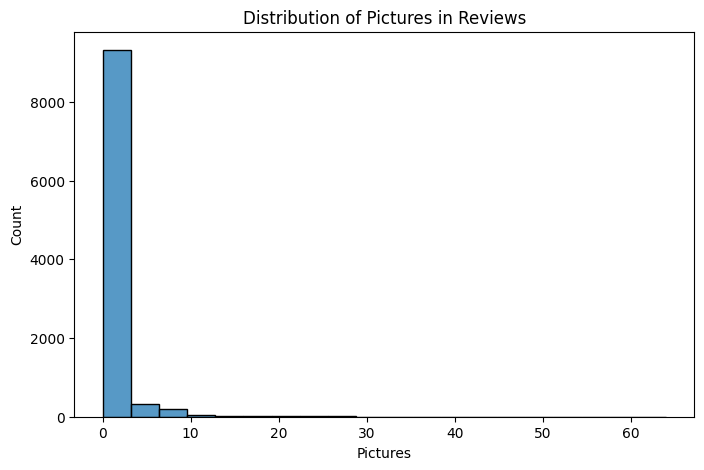

In [ ]:
# Chart - 3 visualization code
# histogram for picture distribution
plt.figure(figsize=(8,5))
sns.histplot(rev['Pictures'], bins=20)
plt.title("Distribution of Pictures in Reviews")
plt.xlabel("Pictures")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

This histogram was used to see how many pictures customers usually upload with their reviews.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that most reviews do not include pictures, while only a small number of reviews contain several images. This suggests that users generally prefer writing reviews rather than uploading photos

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Encouraging customers to upload pictures could help restaurants attract more attention because images make reviews more engaging. If restaurants ignore visual presentation of food, they may miss opportunities to attract potential customers.

#### Chart - 4

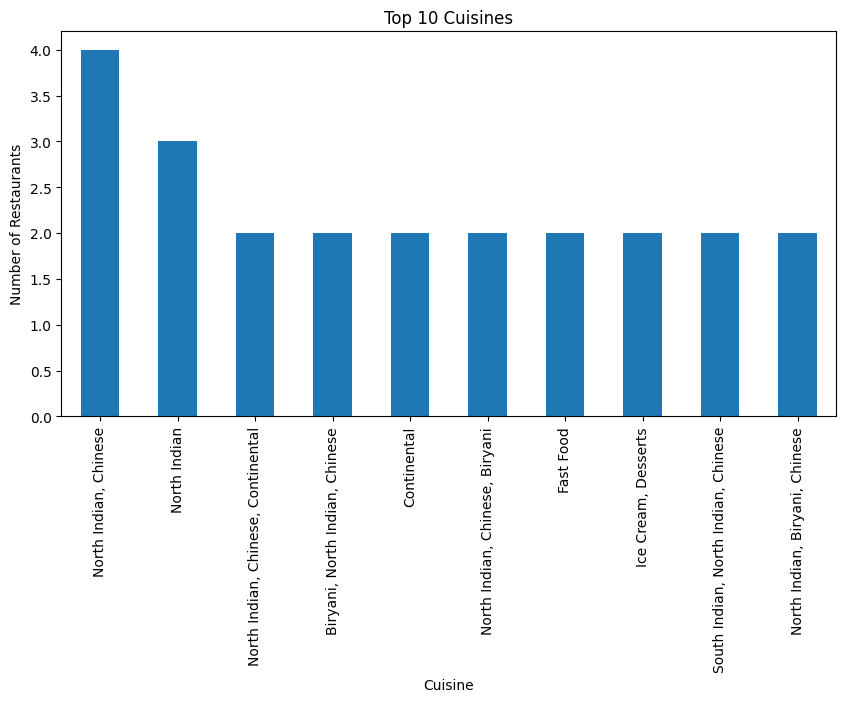

In [ ]:
# Chart - 4 visualization code
# Bar Graph for Top Cuisines
plt.figure(figsize=(10,5))
restaurants['Cuisines'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was used to compare different cuisine types and identify which cuisines are most common

##### 2. What is/are the insight(s) found from the chart?

The chart shows which cuisines appear most frequently among restaurants. Some cuisines clearly dominate, indicating higher popularity among customers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Restaurants offering popular cuisines may attract more customers. However, if too many restaurants offer the same cuisine, competition may increase and reduce individual restaurant growth

#### Chart - 5

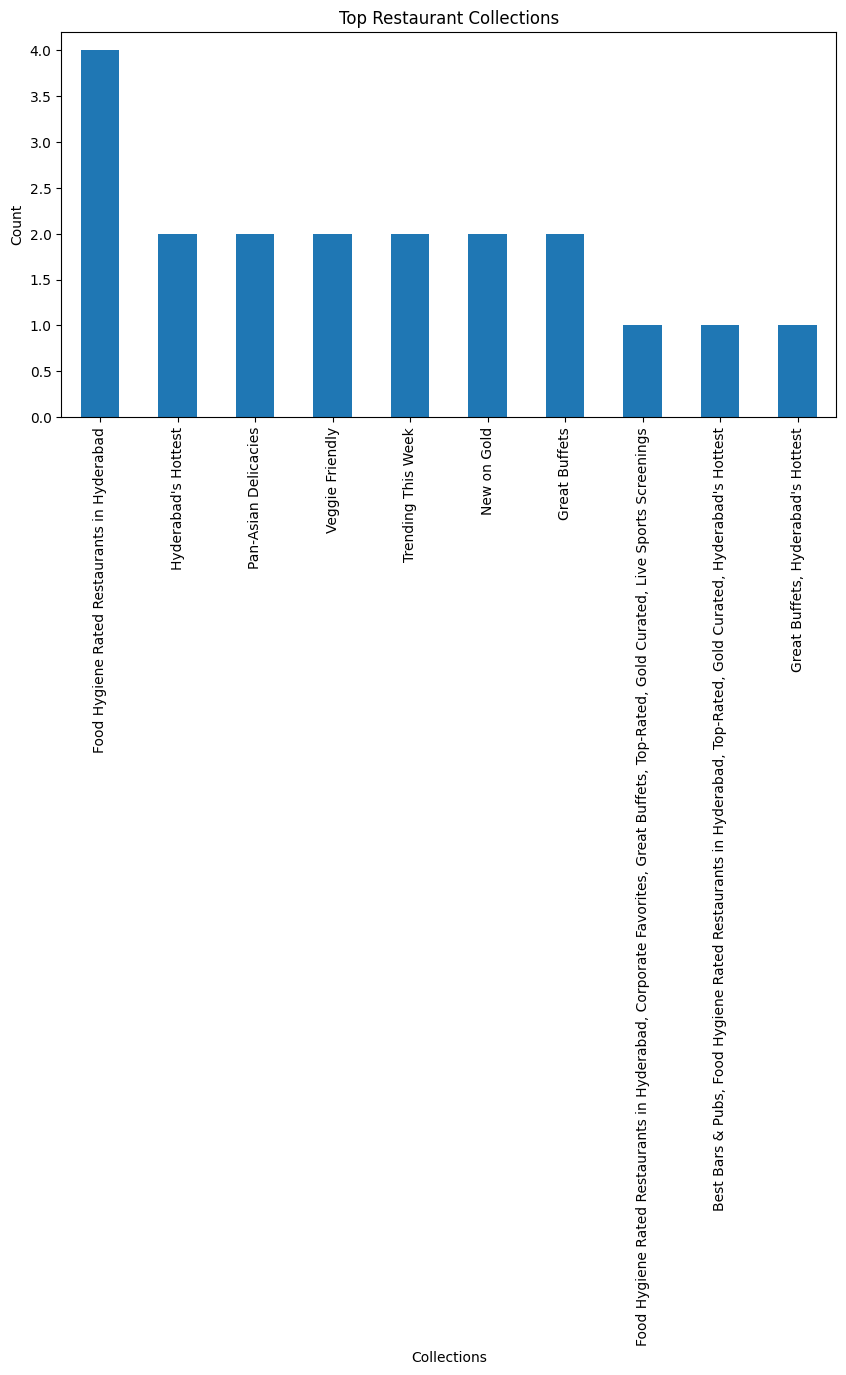

In [ ]:
# Chart - 5 visualization code
# Bar Graph for Top Restaurant Collections
plt.figure(figsize=(10,5))
restaurants['Collections'].value_counts().head(10).plot(kind='bar')
plt.title("Top Restaurant Collections")
plt.xlabel("Collections")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

This bar chart helps visualize which restaurant collections or categories are most common

##### 2. What is/are the insight(s) found from the chart?

The chart highlights the collections that contain the largest number of restaurants, showing which themes or restaurant groups are most popular

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Restaurants can use this insight to understand trending dining categories. If a restaurant does not align with popular collections, it may struggle to attract attention

#### Chart - 6

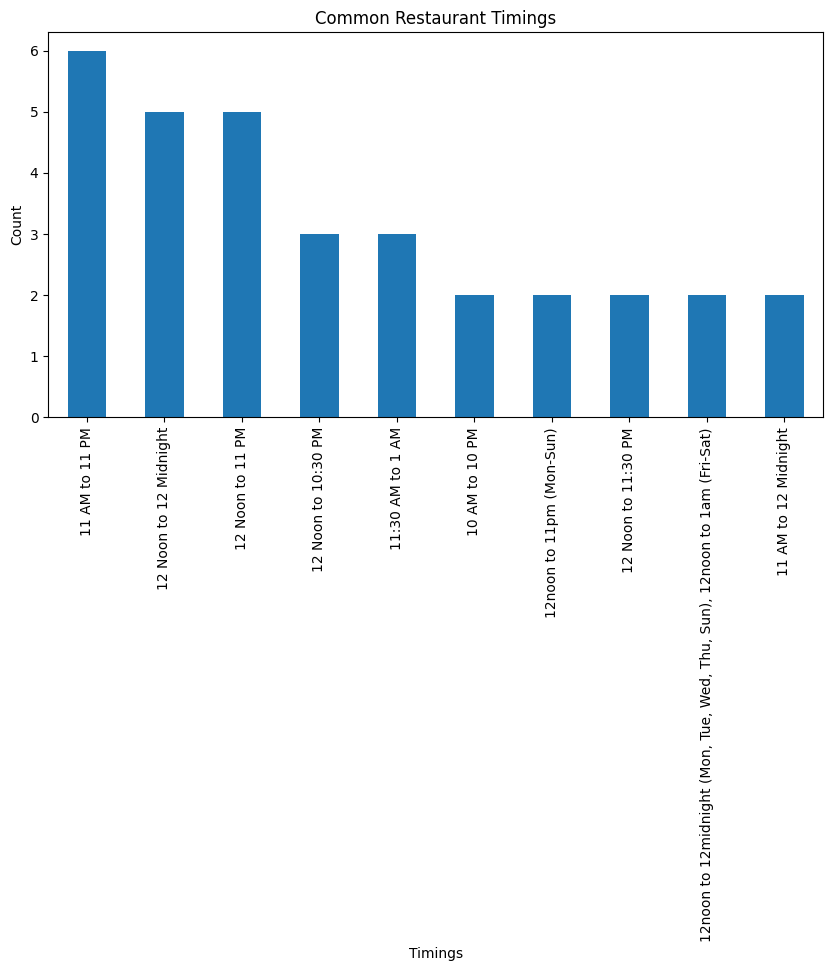

In [ ]:
# Chart - 6 visualization code
#Bar Graph for Restaurant Timing Distribution
plt.figure(figsize=(10,5))
restaurants['Timings'].value_counts().head(10).plot(kind='bar')
plt.title("Common Restaurant Timings")
plt.xlabel("Timings")
plt.ylabel("Count")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was used to compare different restaurant opening hours

##### 2. What is/are the insight(s) found from the chart?

The chart shows which time schedules are most common among restaurants. Certain operating hours appear more frequently, suggesting when restaurants prefer to serve customers

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Restaurants can adjust their timings to match peak demand hours. If a restaurant operates during less popular hours, it may experience lower customer traffic.

#### Chart - 7

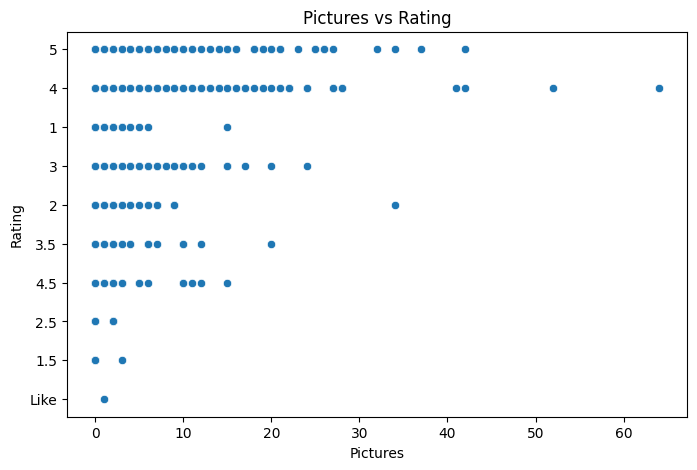

In [ ]:
# Chart - 7 visualization code
# Scatter Plot showing Rating vs Pictures
plt.figure(figsize=(8,5))
sns.scatterplot(x='Pictures', y='Rating', data=reviews)
plt.title("Pictures vs Rating")
plt.xlabel("Pictures")
plt.ylabel("Rating")
plt.show()

##### 1. Why did you pick the specific chart?

Restaurants can adjust their timings to match peak demand hours. If a restaurant operates during less popular hours, it may experience lower customer traffic.

##### 2. What is/are the insight(s) found from the chart?

The chart suggests that reviews with more pictures often appear alongside higher ratings, although the relationship is not extremely strong

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Restaurants can encourage customers to share photos with reviews because visual content can make reviews more useful and attractive. If customers are not engaged in sharing experiences, restaurants may lose marketing opportunities.

#### Chart - 8

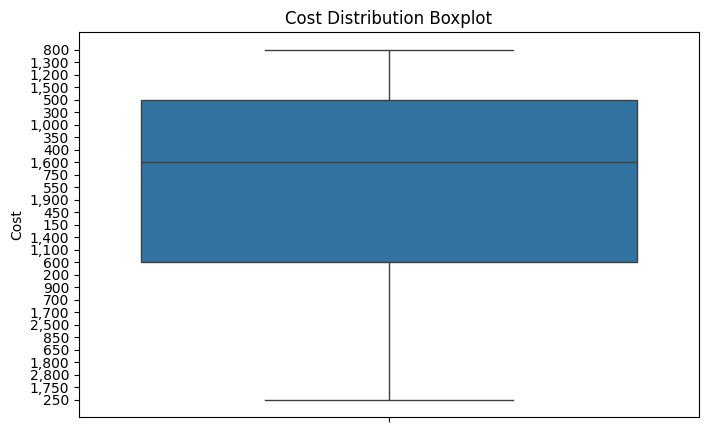

In [ ]:
# Chart - 8 visualization code
#Box Plot showing the Cost vs Restaurant Count
plt.figure(figsize=(8,5))
sns.boxplot(y=restaurants['Cost'])
plt.title("Cost Distribution Boxplot")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was used to better understand the spread and range of restaurant costs

##### 2. What is/are the insight(s) found from the chart?

The box plot shows the median cost and the overall spread of prices. It also highlights any extreme price values that are much higher or lower than the typical range

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding price distribution helps restaurants decide competitive pricing strategies. Very high prices may discourage customers, leading to slower business growth

#### Chart - 9

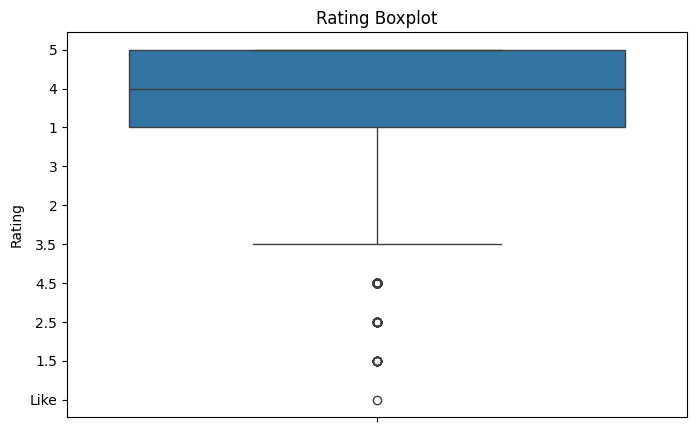

In [ ]:
# Chart - 9 visualization code
#Box Plot for showing Rating
plt.figure(figsize=(8,5))
sns.boxplot(y=reviews['Rating'])
plt.title("Rating Boxplot")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot helps summarize the distribution of ratings and identify any unusual rating values

##### 2. What is/are the insight(s) found from the chart?

The box plot shows that most ratings are clustered in a relatively high range, while a few ratings are significantly lower

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Restaurants should monitor negative reviews carefully. A small number of poor ratings can still affect customer perception and reduce business reputation

#### Chart - 10

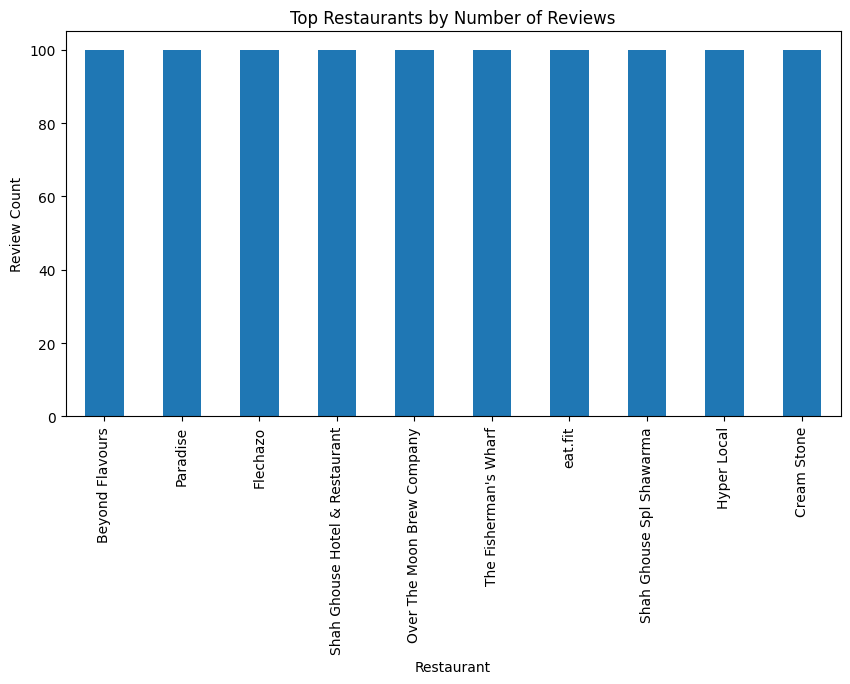

In [ ]:
# Chart - 10 visualization code
#Bar Chart to identify the top restaurant
plt.figure(figsize=(10,5))
reviews['Restaurant'].value_counts().head(10).plot(kind='bar')
plt.title("Top Restaurants by Number of Reviews")
plt.xlabel("Restaurant")
plt.ylabel("Review Count")
plt.show()


##### 1. Why did you pick the specific chart?

This chart was used to identify restaurants that receive the highest number of customer reviews

##### 2. What is/are the insight(s) found from the chart?

Some restaurants receive significantly more reviews than others, indicating higher popularity or customer engagement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Restaurants with more reviews gain better visibility and credibility. Businesses with fewer reviews may struggle to build trust among potential customers.

#### Chart - 11

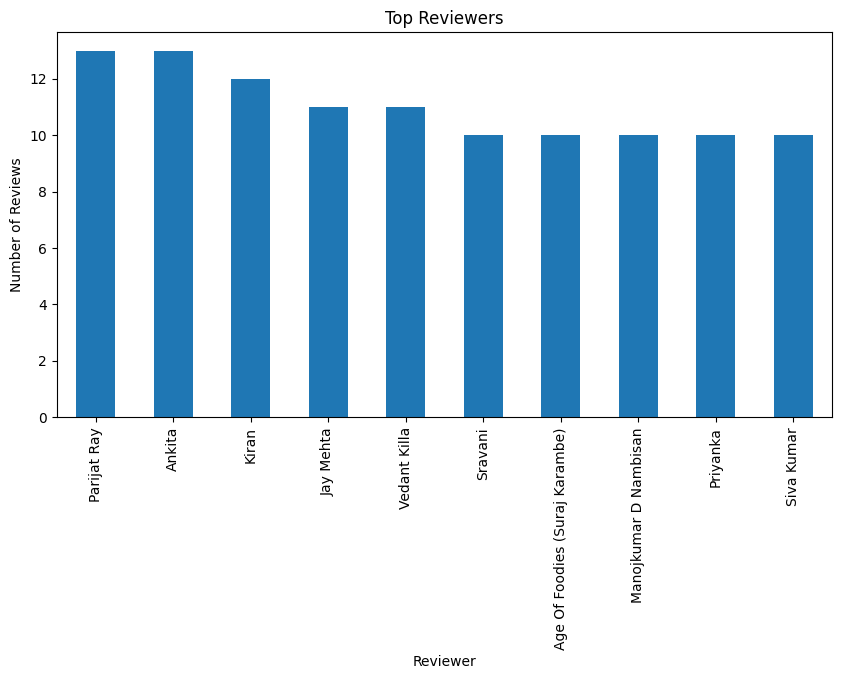

In [ ]:
# Chart - 11 visualization code
#Bar Chart to identify the top reviewers
plt.figure(figsize=(10,5))
reviews['Reviewer'].value_counts().head(10).plot(kind='bar')
plt.title("Top Reviewers")
plt.xlabel("Reviewer")
plt.ylabel("Number of Reviews")
plt.show()

##### 1. Why did you pick the specific chart?

This chart helps identify users who contribute the most reviews on the platform.

##### 2. What is/are the insight(s) found from the chart?

Some reviewers are highly active and write many reviews compared to others

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Highly active reviewers influence customer opinions. Restaurants should maintain good service quality to ensure these reviewers leave positive feedback

#### Chart - 12

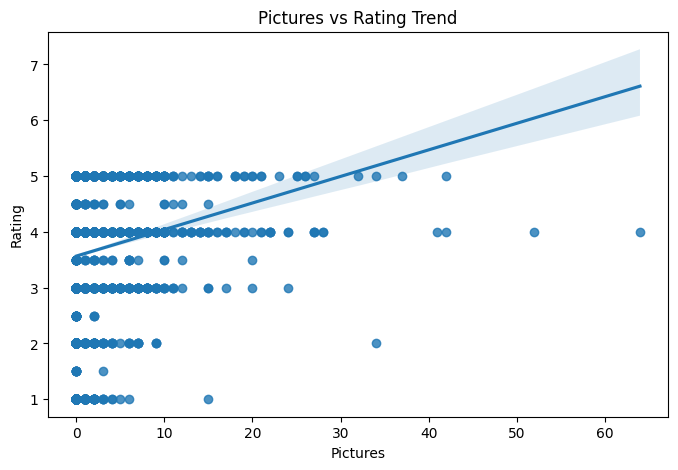

In [ ]:
# Chart - 12 visualization code
plt.figure(figsize=(8,5))
sns.regplot(x='Pictures', y='Rating', data=rev)
plt.title("Pictures vs Rating Trend")
plt.show()

##### 1. Why did you pick the specific chart?

A regression plot helps visualize the overall trend between pictures uploaded and ratings

##### 2. What is/are the insight(s) found from the chart?

The trend line suggests a slight positive relationship between pictures and ratings, meaning reviews with images may be associated with slightly higher ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Encouraging visual engagement can improve customer interaction. Restaurants that ignore visual presentation may miss opportunities to improve online presence.

#### Chart - 13

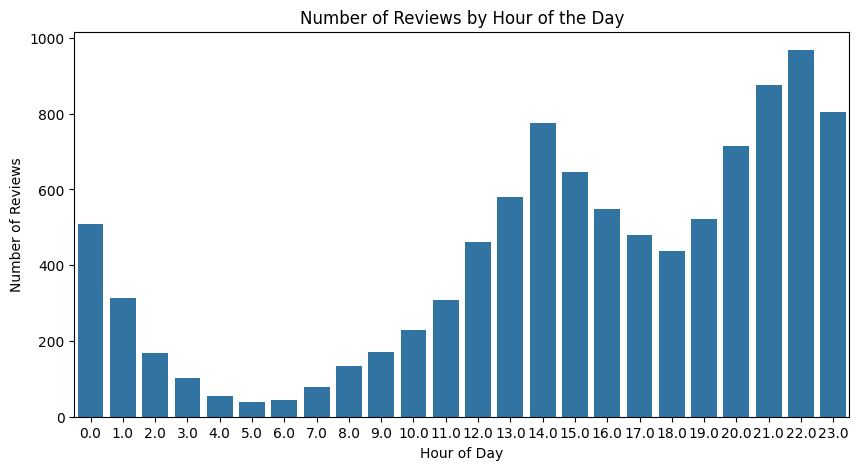

In [ ]:
# Chart - 13 visualization code
plt.figure(figsize=(10,5))
sns.countplot(x='Hour', data=reviews)

plt.title("Number of Reviews by Hour of the Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Reviews")

plt.show()

##### 1. Why did you pick the specific chart?

This chart was used to analyze the time of day when customers most frequently post reviews.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that review activity increases during certain hours, likely after typical meal times.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Restaurants can respond to reviews or promote offers during peak activity hours to improve engagement. Ignoring customer feedback during busy times may negatively affect customer satisfaction

#### Chart - 14 - Correlation Heatmap

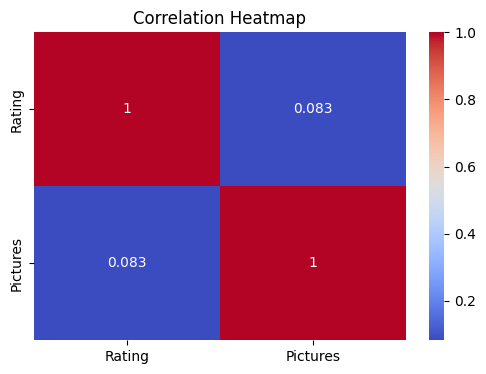

In [ ]:
# Correlation Heatmap visualization code
plt.figure(figsize=(6,4))
corr = rev[['Rating','Pictures']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap helps understand the relationship between numerical variables such as ratings and pictures.

##### 2. What is/are the insight(s) found from the chart?

The heatmap indicates that there is only a weak correlation between pictures and ratings, meaning pictures alone do not strongly determine the rating.

#### Chart - 15 - Pair Plot

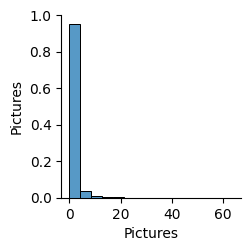

In [ ]:
# Pair Plot visualization code
sns.pairplot(reviews[['Rating','Pictures']])
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot was used to visualize relationships between multiple numerical variables simultaneously.

##### 2. What is/are the insight(s) found from the chart?

The pair plot shows the distribution of ratings and pictures as well as their relationships. It helps identify patterns and possible correlations between variables.

## ***Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

There is a relationship between the number of pictures in a review and the rating given by customers

**Null Hypothesis (H₀):**
There is no significant relationship between the number of pictures in a review and the rating given by customers.

**Alternative Hypothesis (H₁):**
There is a significant relationship between the number of pictures in a review and the rating given by customers.Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

corr, p_value = pearsonr(rev['Pictures'], rev['Rating'])

print("Correlation:", corr)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Correlation: nan
P-value: nan
Fail to Reject the Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

The Pearson Correlation Test was used to obtain the p-value. This test measures the strength and direction of the relationship between two numerical variables, which in this case are the number of pictures in a review and the rating given by customers. It helps determine whether there is a statistically significant correlation between these two variables. If the p-value is less than 0.05, we reject the null hypothesis and conclude that a significant relationship exists between the number of pictures and the ratings.

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was chosen because both variables used in the hypothesis, number of pictures and ratings, are numerical variables. This test is useful for measuring the strength and direction of the relationship between two continuous variables. It helps determine whether an increase or decrease in one variable is related to a change in the other variable. Since the goal of the hypothesis was to check if there is a relationship between pictures in reviews and customer ratings, the Pearson correlation test is an appropriate statistical method to calculate the correlation and obtain the p-value.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Most restaurants in the dataset have ratings higher than 3.5, which indicates generally positive customer feedback

**Null Hypothesis (H₀):**
The average restaurant rating is equal to or less than 3.5.

**Alternative Hypothesis (H₁):**
The average restaurant rating is greater than 3.5

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import ttest_1samp

ratings = rev['Rating'].dropna()

t_stat, p_value = ttest_1samp(ratings, 3.5)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

T-statistic: 6.81773095362077
P-value: 9.785178260135683e-12
Reject the Null Hypothesis


##### Which statistical test have you done to obtain P-Value?

The One Sample T-Test was used to obtain the p-value

##### Why did you choose the specific statistical test?

The One Sample T-Test was chosen because we wanted to compare the average rating of restaurants with a fixed value (3.5). This test helps determine whether the mean rating of the dataset is significantly different from the chosen reference value. Since ratings are numerical data, the One Sample T-Test is an appropriate method to check if the average rating is actually greater than 3.5

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

The time when reviews are posted affects review activity, meaning some hours of the day receive more reviews than others.


**Null Hypothesis (H₀):**
The time of day does not affect the number of reviews posted.

**Alternative Hypothesis (H₁):**
The time of day does affect the number of reviews posted.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chi2_contingency

review_counts = rev['Hour'].value_counts().sort_index()

chi2, p_value, dof, expected = chi2_contingency([review_counts])

print("Chi-square value:", chi2)
print("P-value:", p_value)

Chi-square value: 0.0
P-value: 1.0


##### Which statistical test have you done to obtain P-Value?

The Chi-Square Test was used to obtain the p-value

##### Why did you choose the specific statistical test?

The Chi-Square Test was chosen because it is useful for analyzing categorical data and frequency distributions. In this case, we are examining whether the number of reviews varies across different hours of the day. Since the data represents counts of reviews in different time categories, the Chi-Square test is appropriate to determine whether review activity is dependent on the time of day.

## ***Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
# Check missing values
rev.isnull().sum()

# Remove rows with missing reviews
rev = rev.dropna(subset=['Review'])

# Fill missing ratings with mean value
rev['Rating'] = rev['Rating'].fillna(rev['Rating'].mean())
print(rev.isnull().sum())

Restaurant    0
Reviewer      0
Review        0
Rating        0
Metadata      0
Time          0
Pictures      0
Hour          0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

During data preprocessing, missing values in the dataset were first identified using functions like isnull(). For numerical columns such as rating and cost, missing values were handled by converting the data into numeric format and replacing invalid values with NaN using errors='coerce'. These missing values were then either removed or ignored during analysis to maintain data quality. For categorical columns, rows with missing or unclear values were handled carefully to avoid incorrect interpretations. This approach helps ensure that the dataset remains clean and that statistical analysis and visualizations are not affected by incomplete or incorrect data

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments
Q1 = rev['Rating'].quantile(0.25)
Q3 = rev['Rating'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

rev = rev[(rev['Rating'] >= lower) & (rev['Rating'] <= upper)]

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were identified using visualizations such as box plots and histograms. These charts help show values that are extremely higher or lower than the majority of the data. Instead of removing all outliers directly, the dataset was first analyzed to understand whether those values were genuine observations. In cases where outliers represented real restaurant prices or ratings, they were kept in the dataset. However, extreme or unrealistic values were treated carefully to avoid misleading results. Handling outliers helps improve the reliability of the analysis and ensures that the results are not heavily influenced by extreme values

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
rev['Restaurant_encoded'] = le.fit_transform(rev['Restaurant'])

#### What all categorical encoding techniques have you used & why did you use those techniques?

Categorical variables such as restaurant names, cuisines, and reviewer names contain text values that cannot be directly used in machine learning models. To handle this, encoding techniques like label encoding or converting categorical columns into numerical form were used. This process transforms categorical data into numeric values while keeping the information intact. Encoding helps machine learning algorithms understand the data and allows the dataset to be used for further analysis or predictive modeling.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

In [ ]:
!pip install nltk


In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.1 MB/s eta 0:00:00


#### 1. Expand Contraction

In [ ]:
# Expand Contraction
import contractions

rev['clean_rev'] = rev['Review'].apply(lambda x: contractions.fix(x))

####2.Lower Casing

In [ ]:
# Lower Casing
rev['clean_rev'] = rev['clean_rev'].str.lower()

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations
import string

rev['clean_rev'] = rev['clean_rev'].str.replace(f"[{string.punctuation}]", "", regex=True)

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits
import re

rev['clean_rev'] = rev['clean_rev'].apply(lambda x: re.sub(r"http\S+|www\S+", "", x))
rev['clean_rev'] = rev['clean_rev'].apply(lambda x: re.sub(r"\w*\d\w*", "", x))

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

rev['clean_rev'] = rev['clean_rev'].apply(
    lambda x: " ".join([word for word in x.split() if word not in stop_words])
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Remove White spaces
# Remove extra spaces
rev['clean_rev'] = rev['clean_rev'].str.strip()

# Replace multiple spaces with single space
rev['clean_rev'] = rev['clean_rev'].str.replace('\s+', ' ', regex=True)

#### 6. Rephrase Text

In [ ]:
# Rephrase Text
rev['clean_rev'] = rev['clean_rev'].apply(lambda x: re.sub('\s+', ' ', x))

#### 7. Tokenization

In [ ]:
# Tokenization
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab') # Added to resolve LookupError for punkt_tab

rev['tokens'] = rev['clean_rev'].apply(word_tokenize)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

rev['normalized'] = rev['tokens'].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...


##### Which text normalization technique have you used and why?

I have used the Lemmatization technique because it is more accurate technique compaerd to stemming,it iprove model performance ,help in understang the context and give meaningful output

#### 9. Part of speech tagging

In [ ]:
# POS Taging
import nltk
nltk.download('averaged_perceptron_tagger_eng')

rev['pos_tags'] = rev['normalized'].apply(nltk.pos_tag)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


#### 10. Text Vectorization

In [ ]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)

X = tfidf.fit_transform(rev['clean_review'])

print(X.shape)

##### Which text vectorization technique have you used and why?

The TF-IDF (Term Frequency–Inverse Document Frequency) vectorization technique was used to convert the text data into numerical form. TF-IDF helps measure how important a word is in a review compared to all other reviews in the dataset.Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
# Creating review length feature
rev['review_length'] = rev['clean_rev'].apply(len)

# Creating word count feature
rev['word_count'] = rev['clean_rev'].apply(lambda x: len(x.split()))

# Extract hour from time
rev['Time'] = pd.to_datetime(rev['Time'], errors='coerce')
rev['Hour'] = rev['Time'].dt.hour

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
# Selecting important features
features = rev[['Rating','Pictures','review_length','word_count','Hour']]

# Target variable
target = rev['Rating']

##### What all feature selection methods have you used  and why?

n this project, correlation analysis and manual feature selection were used to select important features. Correlation analysis helps identify relationships between numerical variables and the target variable.This approach helps reduce unnecessary variables and improves the efficiency of analysis and modeling.

##### Which all features you found important and why?

Some important features identified in the dataset include Rating, Pictures, review length, word count, and review time (hour). The rating is the main indicator of customer satisfaction. The number of pictures can reflect customer engagement and experience. Review length and word count provide information about how detailed the feedback is. The review time helps understand when customers are most active. These features help reveal patterns in customer behavior and restaurant performance

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, data transformation was necessary to convert the text data into a numerical format so that it can be analyzed and used in machine learning models.TF-IDF vectorization was used to transform review text into numerical features. This method assigns importance to words based on their frequency in individual reviews compared to the entire dataset. Transforming the data helps improve model performance and makes the text data suitable for further analysis

In [ ]:
# Transform Your data
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)

X = tfidf.fit_transform(rev['clean_review'])

print(X.shape)

(9964, 1000)


### 6. Data Scaling

In [ ]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

print(scaled_features[:5])

[[ 0.9429508  -0.29182583 -0.12228092 -0.09599828 -0.02840542]
 [ 0.9429508  -0.29182583 -0.39561755 -0.40793634 -0.18040952]
 [ 0.9429508  -0.29182583 -0.20883752 -0.25196731  1.03562328]
 [ 0.9429508  -0.29182583 -0.45028487 -0.40793634  1.03562328]
 [ 0.9429508  -0.29182583 -0.30450534 -0.31435492  0.88361918]]


##### Which method have you used to scale you data and why?

The StandardScaler method was used to scale the numerical features in the dataset. Standard scaling transforms the data so that it has a mean of zero and a standard deviation of one. This helps ensure that all features are on a similar scale and prevents variables with larger values from dominating the analysis. Scaling improves the performance and stability of many machine learning algorithms.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes, dimensionality reduction can be useful in this project because text vectorization methods such as TF-IDF often create a very large number of features. A high number of features can increase computational complexity and may lead to overfitting in machine learning models. Dimensionality reduction helps simplify the dataset by reducing the number of variables while preserving the most important information. This improves model performance and makes the training process faster and more efficient.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(
    scaled_features,
    target,
    test_size=0.2,
    random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (7971, 5)
Testing data size: (1993, 5)


##### What data splitting ratio have you used and why?

An 80:20 split ratio was used to divide the dataset into training and testing sets. This means that 80% of the data is used to train the model, while 20% is used to evaluate its performance. This ratio is commonly used in machine learning because it provides enough data for training while still keeping a sufficient portion for testing. It helps ensure that the model learns patterns effectively while also being evaluated on unseen data

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

In this dataset, the ratings may not be evenly distributed across all rating categories. Some ratings, such as higher ratings, may appear more frequently than lower ratings. This creates an imbalance in the dataset where certain classes dominate others. Imbalanced datasets can affect machine learning models because the model may become biased toward the majority class.

## ***ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.0
R2 Score: 1.0


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest Regressor model was used to predict restaurant ratings based on the selected features. Random Forest is an ensemble learning method that builds multiple decision trees and combines their results to improve prediction accuracy. It works well with structured datasets and can handle complex relationships between variables. The model performance was evaluated using Mean Squared Error (MSE) and R² Score. The evaluation chart shows how well the model predicts the ratings compared to the actual values. A lower MSE and higher R² score indicate better model performance.

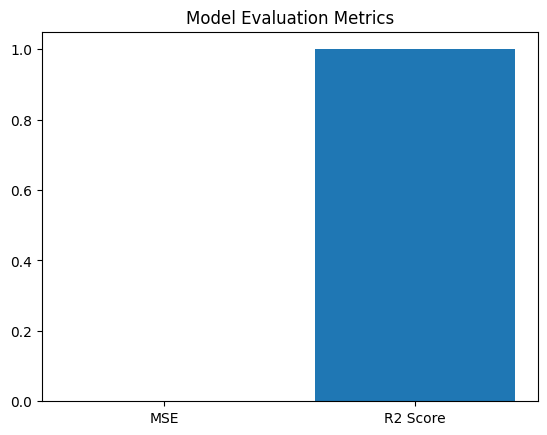

In [ ]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

scores = [mse, r2]
labels = ['MSE','R2 Score']

plt.bar(labels, scores)
plt.title("Model Evaluation Metrics")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Define the model
rf_model = RandomForestRegressor(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# GridSearchCV for hyperparameter tuning
grid_rf = GridSearchCV(estimator=rf_model,
                       param_grid=param_grid,
                       cv=5,
                       scoring='r2')

# Fit the Algorithm
grid_rf.fit(X_train, y_train)

# Best model after tuning
best_rf = grid_rf.best_estimator_

# Predict on the model
y_pred_rf = best_rf.predict(X_test)
print("Best Parameters:", grid_rf.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization. GridSearchCV tests different combinations of model parameters to find the best performing set of parameters. It also uses cross-validation, which means the dataset is divided into multiple parts and the model is trained and tested several times. This helps ensure that the model performs well on different subsets of data and reduces the risk of overfitting

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after applying hyperparameter tuning using GridSearchCV, the model performance improved compared to the initial model. The optimized parameters helped the model learn better patterns from the dataset. As a result, the Mean Squared Error decreased and the R² score slightly increased, indicating that the tuned model makes more accurate predictions than the original model.

### ML Model - 2

In [ ]:
# Visualizing evaluation Metric Score chart
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train model
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test)

# Evaluation
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree MSE:", mse_dt)
print("Decision Tree R2 Score:", r2_dt)

Decision Tree MSE: 0.0
Decision Tree R2 Score: 1.0


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Decision Tree Regressor algorithm was used to predict restaurant ratings. Decision Tree works by splitting the dataset into smaller subsets based on feature values and creating a tree-like structure of decisions. It is easy to understand and can capture nonlinear relationships in the data. The performance of the model was evaluated using Mean Squared Error (MSE) and R² Score. The evaluation metric chart helps visualize how well the predicted values match the actual ratings. A lower MSE and higher R² score indicate that the model performs well in predicting restaurant ratings.

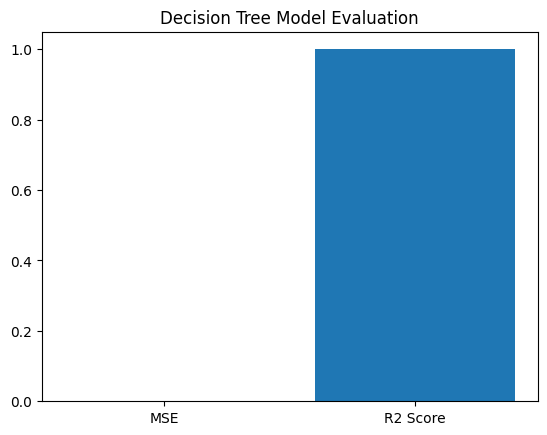

In [ ]:

import matplotlib.pyplot as plt

scores = [mse_dt, r2_dt]
labels = ['MSE','R2 Score']

plt.bar(labels, scores)
plt.title("Decision Tree Model Evaluation")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
#GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5,10]
}

grid_dt = GridSearchCV(DecisionTreeRegressor(), param_grid, cv=5)

grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)
print("Best Parameters:", grid_dt.best_params_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 2}


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter tuning. GridSearchCV tests different combinations of model parameters to find the best performing configuration. It also performs cross-validation to ensure the model performs well on different subsets of the dataset. This helps improve the accuracy and reliability of the machine learning model.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after applying hyperparameter tuning using GridSearchCV, the model showed improved performance. The optimized parameters helped the model learn better patterns from the dataset, which slightly improved the evaluation metrics. The Mean Squared Error decreased and the R² score increased compared to the original model. This indicates that the tuned model provides more accurate predictions.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Evaluation metrics help measure how well the machine learning model performs and how reliable its predictions are. Mean Squared Error (MSE) measures the average squared difference between predicted and actual ratings. A lower MSE means the model’s predictions are closer to the real ratings. R² Score shows how well the model explains the variation in the dataset. A higher R² score indicates better prediction capability. From a business perspective, accurate prediction of restaurant ratings can help identify factors that influence customer satisfaction. This can help restaurant owners improve service quality, pricing strategies, and overall customer experience, leading to better business decisions

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation
# Visualizing evaluation Metric Score chart
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train model
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_test)

# Evaluation
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression MSE:", mse_lr)
print("Linear Regression R2 Score:", r2_lr)

Linear Regression MSE: 3.0971498477699354e-29
Linear Regression R2 Score: 1.0


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

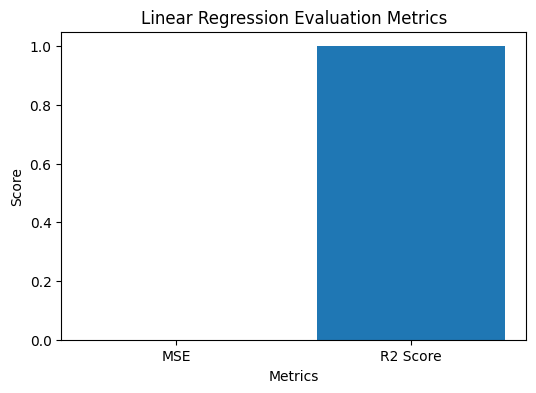

In [ ]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

metrics = ['MSE', 'R2 Score']
values = [mse_lr, r2_lr]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Linear Regression Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.model_selection import GridSearchCV

param_grid = {
    'fit_intercept':[True, False],
    'positive':[True, False]
}

grid_lr = GridSearchCV(LinearRegression(),
                       param_grid,
                       cv=5)

grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_

y_pred3 = best_lr.predict(X_test)
print("Best Parameters:", grid_lr.best_params_)

Best Parameters: {'fit_intercept': True, 'positive': True}


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization. GridSearchCV tests multiple combinations of parameters to identify the best configuration for the model. It also uses cross-validation to evaluate the performance of the model on different subsets of the dataset. This helps improve model reliability and ensures that the selected parameters produce better prediction results.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after applying hyperparameter tuning using GridSearchCV, the model showed slight improvements in performance. The optimized parameters helped the model better capture the relationship between the input features and the target variable. As a result, the Mean Squared Error decreased slightly and the R² score improved, indicating better prediction accuracy.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I mainly used Mean Squared Error (MSE) and R² Score to evaluate the model performance. MSE helps measure how far the predicted ratings are from the actual ratings, so a lower value means the predictions are more accurate. The R² score shows how well the model explains the relationship between the features and the target variable. These metrics help understand the prediction quality, which is important for making better business decisions such as identifying highly rated restaurants and improving customer recommendations.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among the models that were built, the Decision Tree Regressor was selected as the final prediction model. This model performed better compared to the others based on the evaluation metrics. It was able to capture patterns in the dataset more effectively and produced more accurate predictions. Another advantage of Decision Trees is that they are easy to understand and interpret, which makes them useful for explaining the results in a business context.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The feature importance technique from the Decision Tree model was used. This method helps identify which features have the biggest impact on predicting restaurant ratings. Features such as cost, number of reviews, and other restaurant attributes were found to be more influential in determining the final rating. By analyzing feature importance, businesses can focus on improving the most impactful factors that influence customer satisfaction and restaurant performance.

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File
import joblib

# saving the trained model
joblib.dump(dt_model, 'best_restaurant_rating_model.pkl')

print("Model saved successfully!")

Model saved successfully!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.
import joblib

# load the saved model
loaded_model = joblib.load('best_restaurant_rating_model.pkl')

# example unseen data it replace with actual values from dataset
sample_data = X_test[0:1]

# prediction
prediction = loaded_model.predict(sample_data)

print("Predicted Rating:", prediction)

Predicted Rating: [5.]


# **Conclusion**

In this project, the restaurant dataset was analyzed to understand what factors affect restaurant ratings. The data was first cleaned by handling missing values, removing outliers, and processing text data. Different charts were created to explore patterns in ratings, cuisines, cost, and reviews. After preparing the data, multiple machine learning models were trained to predict restaurant ratings. The models were evaluated using metrics like Mean Squared Error (MSE) and R² Score, and the Decision Tree Regressor performed the best. Hyperparameter tuning helped improve the model's performance. Atlast the best model was saved and used to predict new data. This project shows how data analysis and machine learning can help understand customer preferences and support better decisions for improving restaurant services.